In [5]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [10]:
class cricketstate(TypedDict):
    runs:int
    balls:int
    fours: int
    sixs:int

    strikerate: float
    bpb: float
    boundarypercent: float
    summary: str

In [33]:
def calculatesr(state: cricketstate):

    sr = (state['runs']/state['balls'])*100
    return {'strikerate': sr}

In [34]:
def calculate_bpb(state: cricketstate):

    bpb = state['balls']/(state['fours']+state['sixs'])
    return {'bpb':bpb}

In [35]:
def calculate_boundarypercent(state: cricketstate):

    bpc = (((state['fours']*4)+ (state['sixs']*6))/state['runs'])*100
    return {'boundarypercent':bpc}

In [36]:
def summary(state: cricketstate):
    summary = f"""Strike Rate: {state['strikerate']}
    Balls per boundary: {state['bpb']}"""
    return {'summary':summary}

In [37]:
graph = StateGraph(cricketstate)
graph.add_node('calculate_sr',calculatesr)
graph.add_node('calculate_bpb',calculate_bpb)
graph.add_node('calculate_boundarypercent',calculate_boundarypercent)
graph.add_node('summary',summary)


graph.add_edge(START,'calculate_sr')
graph.add_edge(START,'calculate_bpb')
graph.add_edge(START,'calculate_boundarypercent')

graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_bpb','summary')
graph.add_edge('calculate_boundarypercent','summary')


graph.add_edge('summary',END)

workflow = graph.compile()

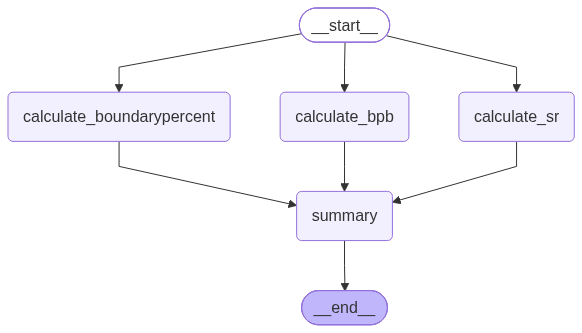

In [38]:
workflow

In [39]:
initial_state={'runs': 100, 'balls': 50, 'sixs':2, 'fours': 4}

In [40]:
final_state = workflow.invoke(initial_state)

In [41]:
final_state

{'runs': 100,
 'balls': 50,
 'fours': 4,
 'sixs': 2,
 'strikerate': 200.0,
 'bpb': 8.333333333333334,
 'boundarypercent': 28.000000000000004,
 'summary': 'Strike Rate: 200.0\n    Balls per boundary: 8.333333333333334'}